# Digit Predicator 

## Load the dataset

In [1]:
import torchvision.datasets as datasets
from torchvision.transforms import v2
import torch


# Define image transformation to Tensor
transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

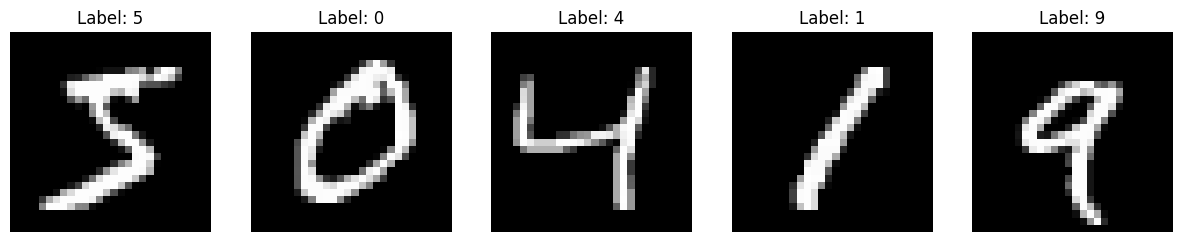

In [2]:
import matplotlib.pyplot as plt

# Visualize some samples from the training dataset
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    image, label = train_dataset[i]
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')
plt.show()

### 1. Define and Train the CNN Model
We'll define a ResNet Convolutional Neural Network (CNN) suitable for MNIST.

In [3]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class ResNetDigit(nn.Module):
    def __init__(self):
        super(ResNetDigit, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = ResidualBlock(16, 16)
        self.layer2 = ResidualBlock(16, 32, stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(32, 10)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = ResNetDigit()
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training ResNet model...")
model.train()
for epoch in range(2):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Epoch: {epoch} [{batch_idx * len(data)}/60000] Loss: {loss.item():.4f}')

Training ResNet model...
Epoch: 0 [0/60000] Loss: 2.3091
Epoch: 0 [12800/60000] Loss: 1.4550
Epoch: 0 [25600/60000] Loss: 0.9003
Epoch: 0 [38400/60000] Loss: 0.6229
Epoch: 0 [51200/60000] Loss: 0.3596
Epoch: 1 [0/60000] Loss: 0.3160
Epoch: 1 [12800/60000] Loss: 0.2889
Epoch: 1 [25600/60000] Loss: 0.1908
Epoch: 1 [38400/60000] Loss: 0.1978
Epoch: 1 [51200/60000] Loss: 0.1727


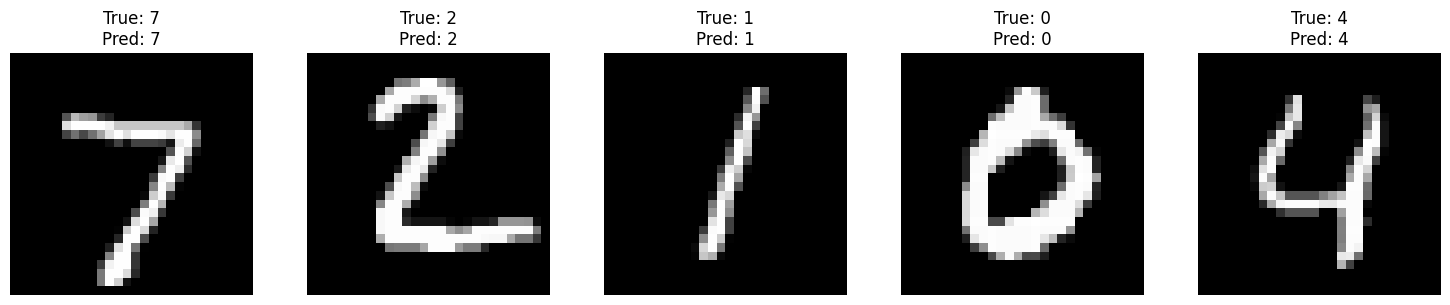

In [4]:
import matplotlib.pyplot as plt
import torch

# Set model to evaluation mode
model.eval()

# Pick 5 random samples from the test dataset
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

with torch.no_grad():
    for i in range(5):
        # Get a sample from the test dataset
        image, label = test_dataset[i]
        
        # Prepare image for prediction (add batch dimension)
        input_tensor = image.unsqueeze(0)
        
        # Forward pass
        output = model(input_tensor)
        prediction = torch.argmax(output, dim=1).item()
        
        # Plot the result
        axes[i].imshow(image.squeeze(), cmap='gray')
        axes[i].set_title(f'True: {label}\nPred: {prediction}')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

### 2. Export the Model to ONNX
ONNX (Open Neural Network Exchange) allows for interoperability between different frameworks and faster inference.

In [5]:
!pip install onnx onnxscript

import torch.onnx

# Set model to evaluation mode
model.eval()

# Create a dummy input matching the model's input shape
dummy_input = torch.randn(1, 1, 28, 28)

# Export the model
torch.onnx.export(model, dummy_input, "mnist_cnn.onnx", 
                  input_names=['input'], output_names=['output'], 
                  dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}})

print("Model successfully exported to mnist_cnn.onnx")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 80.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 12.2 MB/s eta 0:00:00


/tmp/ipykernel_12729/2694584025.py:12: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(model, dummy_input, "mnist_cnn.onnx",


[torch.onnx] Obtain model graph for `ResNetDigit([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNetDigit([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model successfully exported to mnist_cnn.onnx


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
